In [197]:
import pandas as pd

PATH_XLSX = r'C:\Users\Pablo\Documents\GitHub\BusinessMapAtecna\data\raw\DatosBusquedaAvanzada20250208.xlsx'

# BusinessMap sheet viene con 2 primeras filas especiales, fila 2 = headers reales

bm_raw = pd.read_excel(PATH_XLSX, sheet_name='Businessmap', header=None)
bm_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,1406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Card ID,Color,Owner,Deadline,Priority,Column Name,Board Name,Lane Name,Attachments,Blocked State,...,Last Date Moved To A empezar (PROYECTOS),Last Date Moved To En progreso (PROYECTOS),Last Date Moved To Testeos internos (PROYECTOS),Last Date Moved To Pilotos / Batería de prueba...,Last Date Moved To Finalizado (PROYECTOS),Last Date Moved To Ready to Archive (PROYECTOS),Last Modified,Last Moved,Watched,Effective Subtask Parent Card ID
2,7662,#34a97b,Técnico 11,NaN,Average,Ready to Archive,PROYECTOS,TAREAS,NaN,no,...,2025-06-26 14:42:03,2025-06-27 09:25:44,NaN,NaN,2025-06-27 09:27:17,2025-07-02 08:46:42,2025-07-02 09:02:26,2025-07-02 08:46:42,NaN,NaN
3,7653,#34a97b,Técnico 1,NaN,Average,Ready to Archive,PROYECTOS,TAREAS,NaN,no,...,2025-06-26 11:10:43,2025-06-26 11:11:55,2025-06-26 11:50:32,NaN,2025-06-27 14:23:30,2025-07-31 09:15:33,2025-08-08 06:30:11,2025-07-31 09:15:33,NaN,NaN
4,7648,#34a97b,Consultor 5,NaN,Average,Ready to Archive,PROYECTOS,TAREAS,NaN,no,...,NaN,2025-06-26 10:29:38,2025-06-26 10:50:33,NaN,2025-08-22 08:04:14,2025-09-05 12:00:43,2025-09-13 06:30:17,2025-09-05 12:00:43,NaN,NaN


In [198]:
# Fila 2 (index 1) = headers reales
headers = bm_raw.iloc[1].astype(str).tolist()

# Desde fila 3 (index 2) = datos
bm = bm_raw.iloc[2:].copy()
bm.columns = headers
bm.reset_index(drop=True, inplace=True)

# Otras vistas (headers normales)
links = pd.read_excel(PATH_XLSX, sheet_name='Links')
subtasks = pd.read_excel(PATH_XLSX, sheet_name='Subtasks')

bm.shape, links.shape, subtasks.shape

((1406, 87), (606, 15), (1341, 7))

Deja bm, links, subtasks listos con dimensiones visibles

In [199]:
# Drop columnas 100% nulas
bm = bm.dropna(axis=1, how='all')

# Normalizar nombres de columnas (espacios, saltos raros)
bm.columns = (
    bm.columns.astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
)

# Normalizar strings sin convertir NaN en texto literal
obj_cols = bm.select_dtypes(include='object').columns
bm[obj_cols] = bm[obj_cols].apply(
    lambda s: s.map(lambda v: ' '.join(v.split()) if isinstance(v, str) else v)
)
bm[obj_cols] = bm[obj_cols].replace({'': pd.NA})

bm.shape

(1406, 79)

Reduce ruido y evita que "Owner " y "Owner" sean “distintos”

In [200]:
# Parseo de fechas
date_cols = ['Deadline', 'Created At', 'Actual End Date', 'Start Date', 'Actual Start Date', 'Firts Requested Date', 'Last Requested Date', 'End Date', 'Planned End', 'Planned Start', 'Last Date Moved Out Of Backlog (PROYECTOS)', 'Last Date Moved Out Of A empezar (PROYECTOS)', 'Last Date Moved Out Of En progreso (PROYECTOS)', 'Last Date Moved Out Of Testeos internos (PROYECTOS)',
                   'Last Date Moved Out Of Pilotos / Batería de pruebas (PROYECTOS)', 'Last Date Moved Out Of Finalizado (PROYECTOS)', 'Last Date Moved Out Of Ready to Archive (PROYECTOS)', 'First End Date', 'First Start Date', 'First Date Moved To Backlog (PROYECTOS)', 'First Date Moved To A empezar (PROYECTOS)', 'First Date Moved To En progreso (PROYECTOS)', 'First Date Moved To Testeos internos (PROYECTOS)',
                     'First Date Moved To Pilotos / Batería de pruebas (PROYECTOS)', 'First Date Moved To Finalizado (PROYECTOS)', 'First Date Moved To Ready to Archive (PROYECTOS)', 'Last Date Moved To Backlog (PROYECTOS)', 'Last Blocked Date', 'Last End Date', 'Last Start Date', 'Last Date Moved To A empezar (PROYECTOS)', 'Last Date Moved To En progreso (PROYECTOS)', 'Last Date Moved To Testeos internos (PROYECTOS)',
                     'Last Date Moved To Pilotos / Batería de pruebas (PROYECTOS)', 'Last Date Moved To Finalizado (PROYECTOS)', 'Last Date Moved To Ready to Archive (PROYECTOS)', 'Last Modified', 'Last Moved']

date_cols = [c for c in date_cols if c in bm.columns]

for c in date_cols:
    bm[c] = pd.to_datetime(bm[c], errors='coerce')

date_cols[:10], len(date_cols)

(['Deadline',
  'Created At',
  'Actual End Date',
  'Start Date',
  'Actual Start Date',
  'End Date',
  'Planned End',
  'Planned Start',
  'Last Date Moved Out Of Backlog (PROYECTOS)',
  'Last Date Moved Out Of A empezar (PROYECTOS)'],
 36)

In [201]:
bm['is_closed'] = bm['Actual End Date'].notna()

bm['duration_days'] = (
    (bm['Actual End Date'] - bm['Actual Start Date'])
    .dt.total_seconds() / 86400
)

In [202]:
DATE_FIELDS = {
    "created": "Created At",
    "actual_start": "Actual Start Date",
    "actual_end": "Actual End Date",
    "deadline": "Deadline",
    "planned_start": "Planned Start",
    "planned_end": "Planned End"
}

# Verificar que existen en el dataset
missing = {k: v in bm.columns for k, v in DATE_FIELDS.items()}
missing

{'created': True,
 'actual_start': True,
 'actual_end': True,
 'deadline': True,
 'planned_start': True,
 'planned_end': True}

In [203]:
# Checks obligatorios

summary = {}

summary['n_rows'] = len(bm)
summary['n_closed'] = int(bm['is_closed'].sum())
summary['n_open'] = int((~bm['is_closed']).sum())

# Duraciones solo en cerradas (y no nulas)
dur = bm.loc[bm['is_closed'] & bm['duration_days'].notna(), 'duration_days']

summary["dur_count"] = int(dur.shape[0])
summary["dur_negative"] = int((dur < 0).sum())
summary["dur_zero"] = int((dur == 0).sum())
summary["dur_p50"] = float(dur.median()) if len(dur) else None
summary["dur_p90"] = float(dur.quantile(0.90)) if len(dur) else None
summary["dur_max"] = float(dur.max()) if len(dur) else None

pd.Series(summary)

n_rows          1406.000000
n_closed        1359.000000
n_open            47.000000
dur_count       1359.000000
dur_negative       0.000000
dur_zero         178.000000
dur_p50            4.059213
dur_p90           54.958706
dur_max          300.772836
dtype: float64

In [204]:
dur = bm.loc[bm['is_closed'] & bm['duration_days'].notna(), 'duration_days']

print('Min:', dur.min())
print('P50:', dur.median())
print('P90:', dur.quantile(0.90))
print('Max:', dur.max())
print('Negativas:', (dur < 0).sum())

Min: 0.0
P50: 4.059212962962963
P90: 54.95870601851853
Max: 300.77283564814815
Negativas: 0


In [205]:
# Limpieza minima de duracion (para analisis/modelo)

# Dataset para modelado ETA: solo cerradas con duración válida
bm_eta = bm.loc[bm['is_closed'] & bm['duration_days'].notna()].copy()

# Reglas minimas: quitar negativas, quitar outliers extremos (por encima de p99)
bm_eta = bm_eta.loc[bm_eta['duration_days'] >= 0]

p99 = bm_eta['duration_days'].quantile(0.99) if len(bm_eta) else None
if p99 is not None:
    bm_eta = bm_eta.loc[bm_eta['duration_days'] <= p99]

bm_eta.shape, p99

((1345, 81), np.float64(187.14373680555573))

Deja bm_eta listo para empezar EDA + baseline ETA sin que un 1% de casos raros destrocen todo

In [206]:
dur = bm.loc[bm["is_closed"] & bm["duration_days"].notna(), "duration_days"]

print("Min:", dur.min())
print("P50:", dur.median())
print("P90:", dur.quantile(0.90))
print("Max:", dur.max())
print("Negativas:", (dur < 0).sum())

Min: 0.0
P50: 4.059212962962963
P90: 54.95870601851853
Max: 300.77283564814815
Negativas: 0


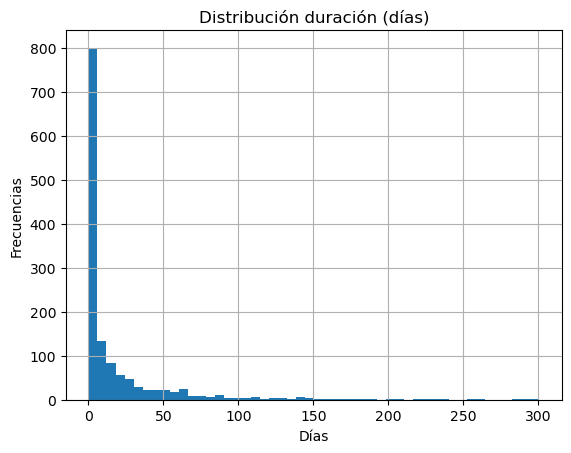

In [207]:
# EDA
import matplotlib.pyplot as plt

plt.figure()
dur.hist(bins=50)
plt.title('Distribución duración (días)')
plt.xlabel('Días')
plt.ylabel('Frecuencias')
plt.show()

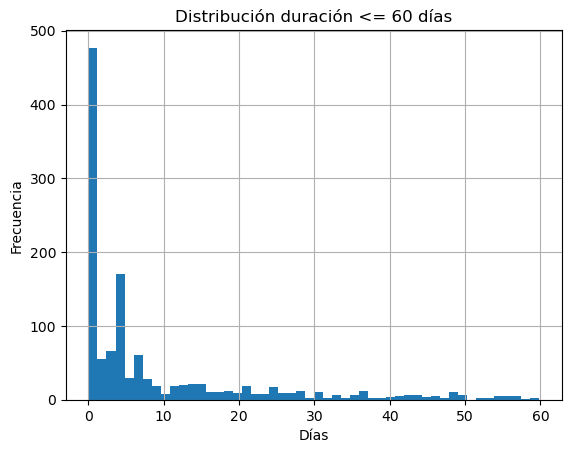

In [208]:
plt.figure()
dur[dur <= 60].hist(bins=50)
plt.title("Distribución duración <= 60 días")
plt.xlabel("Días")
plt.ylabel("Frecuencia")
plt.show()

In [209]:
# Duración mediana por owner (solo cerradas)
owner_col = "Owner"  # confirma el nombre exacto

owner_duration = (
    bm_eta.groupby(owner_col)["duration_days"]
    .median()
    .sort_values()
)

print(owner_duration.head(10), owner_duration.tail(10))

bm_eta[owner_col].value_counts()

Owner
Consultor 2    0.000000
Consultor 5    0.000069
Técnico 2      0.002188
Técnico 9      0.849016
Técnico 1      0.991013
Técnico 8      2.459456
Técnico 12     2.565480
Técnico 5      4.024803
Técnico 11     6.069618
Consultor 3    6.393889
Name: duration_days, dtype: float64 Owner
Consultor 3     6.393889
Técnico 10      6.452124
Técnico 6      10.879410
Técnico 3      12.017975
Técnico 4      13.760278
Consultor 6    14.988241
Consultor 4    14.999144
Técnico 7      15.003646
Consultor 1    20.896348
Otros 2        30.979456
Name: duration_days, dtype: float64


Owner
Técnico 5      232
Técnico 11     153
Técnico 9      120
Técnico 8      109
Técnico 1      104
Consultor 5    103
Consultor 1     70
Técnico 2       70
Técnico 7       69
Técnico 4       68
Técnico 6       46
Técnico 3       45
Consultor 4     35
Consultor 3     33
Consultor 6     31
Técnico 12      22
Técnico 10      16
Otros 2         16
Consultor 2      3
Name: count, dtype: int64

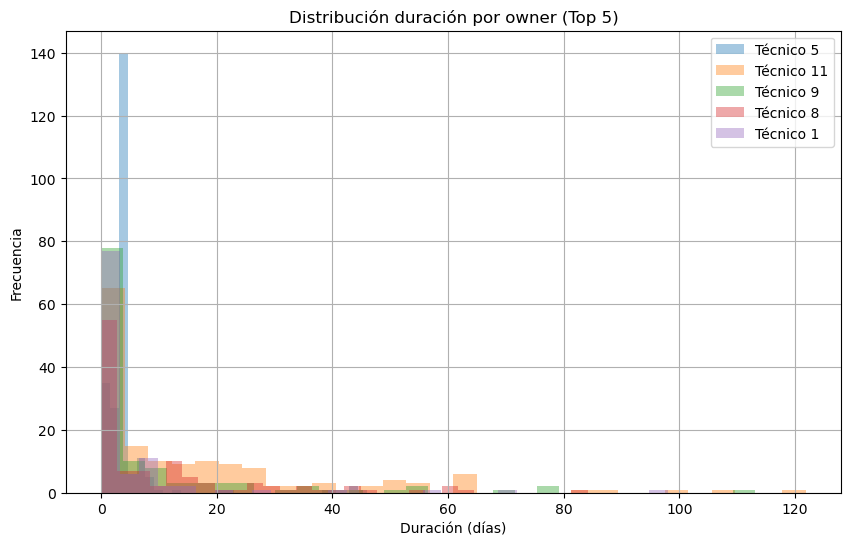

In [210]:
import matplotlib.pyplot as plt

top_owners = bm_eta["Owner"].value_counts().head(5).index

plt.figure(figsize=(10,6))

for owner in top_owners:
    subset = bm_eta[bm_eta["Owner"] == owner]["duration_days"]
    subset.hist(bins=30, alpha=0.4, label=owner)

plt.legend()
plt.xlabel("Duración (días)")
plt.ylabel("Frecuencia")
plt.title("Distribución duración por owner (Top 5)")
plt.show()

### Análisis de duración de tareas por responsable

Se ha analizado la distribución de la duración de las tareas (`duration_days`) para los responsables con mayor número de tareas.

**Observaciones principales:**

- La mayor parte de las tareas se resuelven en **menos de 10 días**, con una concentración fuerte entre **0 y 5 días**.
- La distribución presenta una **cola larga (heavy tail)**, con algunas tareas que alcanzan duraciones superiores a **100 días**.
- Existen diferencias relevantes entre responsables:
  - Algunos responsables tienen una duración mediana cercana a **1–2 días**.
  - Otros presentan medianas superiores a **10–20 días**.
- Estas diferencias indican que el **responsable (Owner) es una variable potencialmente predictiva** para estimar el tiempo de resolución de una tarea.

**Implicaciones para el modelado:**

- La variable `Owner` se considerará como feature en el modelo de estimación de ETA.
- Debido a la asimetría de la distribución de duración, es probable que sea necesario aplicar una **transformación logarítmica (`log(duration + 1)`)** para estabilizar la varianza antes del entrenamiento del modelo.

In [211]:
# Fecha de referencia (última fecha del dataset)
reference_date_cols = [
    DATE_FIELDS["created"],
    DATE_FIELDS["actual_end"],
    "Last Modified",
    "Last Moved",
]
reference_date_cols = [c for c in reference_date_cols if c in bm.columns]

reference_date = bm[reference_date_cols].max().max()

# Edad de la tarea en días
bm["age_days"] = (
    reference_date - bm[DATE_FIELDS["created"]]
).dt.total_seconds() / 86400
# Usamos la última fecha del dataset como referencia para simular "hoy".

print("reference_date:", reference_date)
bm["age_days"].describe()

reference_date: 2026-02-08 01:16:27


count    1406.000000
mean      247.803220
std       107.289623
min        43.645891
25%       155.642989
50%       261.637946
75%       327.660813
max       659.638449
Name: age_days, dtype: float64

### Edad de las tareas

Se calcula la edad de cada tarea (`age_days`) como la diferencia entre la fecha de referencia del dataset y la fecha de creación.

Esta variable representa cuánto tiempo lleva existiendo una tarea y puede ser un indicador relevante para estimar el tiempo restante hasta su resolución (ETA).

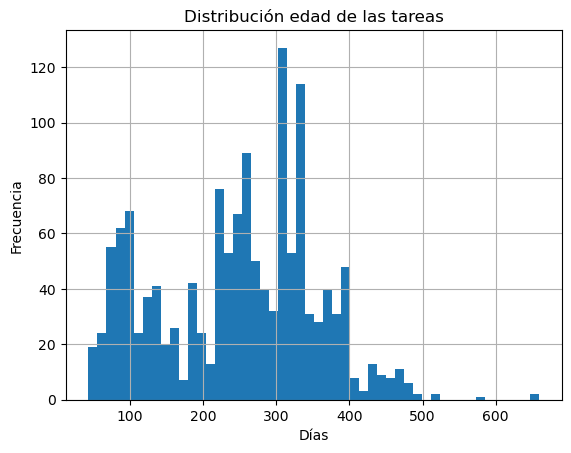

In [212]:
import matplotlib.pyplot as plt

plt.figure()
bm["age_days"].hist(bins=50)
plt.title("Distribución edad de las tareas")
plt.xlabel("Días")
plt.ylabel("Frecuencia")
plt.show()

### Edad de las tareas (age_days)

Se calcula la edad de cada tarea como la diferencia entre la fecha de referencia del dataset y la fecha de creación.

Observaciones:

- La mediana de edad es ~218 días.
- Existen tareas con más de 600 días desde su creación.
- Esto refleja que el dataset incluye histórico completo y no solo tareas recientes.

La variable `age_days` se utilizará como feature para el modelo de estimación de ETA.

In [213]:
# Normalizar IDs para que tengan el mismo tipo
bm["Card ID"] = pd.to_numeric(bm["Card ID"], errors="coerce")
subtasks["Parent Card ID"] = pd.to_numeric(subtasks["Parent Card ID"], errors="coerce")

# Comprobar tipos
print(bm["Card ID"].dtype)
print(subtasks["Parent Card ID"].dtype)

int64
int64


In [214]:
# Número de subtareas por card
subtasks_count = (
    subtasks.groupby("Parent Card ID")
    .size()
    .rename("subtasks_count")
)

# Unir al dataset principal
bm = bm.merge(
    subtasks_count,
    left_on="Card ID",
    right_index=True,
    how="left"
)

# Las tareas sin subtareas = 0
bm["subtasks_count"] = bm["subtasks_count"].fillna(0)

bm["subtasks_count"].describe()

count    1406.000000
mean        0.955192
std         2.415280
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        29.000000
Name: subtasks_count, dtype: float64

### Integración con subtareas

Antes de unir la vista principal con la tabla de subtareas, se normalizan los identificadores (`Card ID` y `Parent Card ID`) a formato numérico para garantizar una unión consistente entre ambas fuentes.

In [215]:
# Flag: la tarea tiene subtareas
bm["has_subtasks"] = (bm["subtasks_count"] > 0).astype(int)

bm["has_subtasks"].value_counts()

has_subtasks
0    1082
1     324
Name: count, dtype: int64

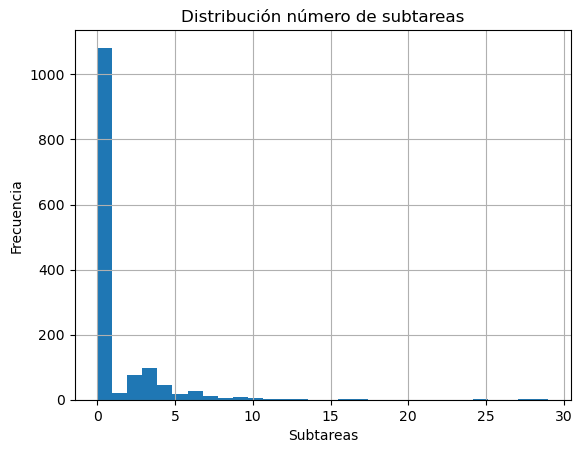

In [216]:
import matplotlib.pyplot as plt

plt.figure()
bm["subtasks_count"].hist(bins=30)
plt.title("Distribución número de subtareas")
plt.xlabel("Subtareas")
plt.ylabel("Frecuencia")
plt.show()

### Subtareas por tarea

Se calcula el número de subtareas asociadas a cada card (`subtasks_count`).

Observaciones:

- La mayoría de tareas no tienen subtareas.
- Existe un pequeño grupo con múltiples subtareas (hasta 29).
- Se crea también un feature binario (`has_subtasks`) para indicar si una tarea tiene o no subtareas.

In [217]:
links.columns.tolist()

['Card ID',
 'Custom ID',
 'Linked Card ID',
 'Link Type',
 'Board Name',
 'Workflow Name',
 'Section',
 'Column Name',
 'Lane Name',
 'Owner',
 'Type Name',
 'Color',
 'Priority',
 'Deadline',
 'Size']

In [218]:
# Normalizar IDs en la tabla links
links["Card ID"] = pd.to_numeric(links["Card ID"], errors="coerce").astype("Int64")
links["Linked Card ID"] = pd.to_numeric(links["Linked Card ID"], errors="coerce").astype("Int64")

# Links salientes: cuántas cards enlaza cada tarea
outgoing_links = (
    links.groupby("Card ID")
    .size()
    .rename("outgoing_links_count")
)

# Links entrantes: cuántas veces una tarea aparece enlazada por otras
incoming_links = (
    links.groupby("Linked Card ID")
    .size()
    .rename("incoming_links_count")
)

# Merge al dataset principal
bm = bm.merge(
    outgoing_links,
    left_on="Card ID",
    right_index=True,
    how="left"
)

bm = bm.merge(
    incoming_links,
    left_on="Card ID",
    right_index=True,
    how="left"
)

# Rellenar nulos
bm["outgoing_links_count"] = bm["outgoing_links_count"].fillna(0)
bm["incoming_links_count"] = bm["incoming_links_count"].fillna(0)

# Total de links
bm["total_links_count"] = bm["outgoing_links_count"] + bm["incoming_links_count"]

bm[["outgoing_links_count", "incoming_links_count", "total_links_count"]].describe()

,outgoing_links_count,incoming_links_count,total_links_count
count,1406.000000,1406.000000,1406.000000
mean,0.018492,0.437411,0.455903
std,0.183906,0.569693,0.651724
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000
max,4.000000,6.000000,10.000000


Esto significa:

La mayoría de tareas no tienen dependencias.

Un grupo menor tiene 1 dependencia.

Muy pocas tienen muchas dependencias.

In [219]:
bm["has_outgoing_links"] = (bm["outgoing_links_count"] > 0).astype(int)
bm["has_incoming_links"] = (bm["incoming_links_count"] > 0).astype(int)
bm["has_any_links"] = (bm["total_links_count"] > 0).astype(int)

bm[["has_outgoing_links", "has_incoming_links", "has_any_links"]].sum()

has_outgoing_links     18
has_incoming_links    585
has_any_links         589
dtype: int64

### Dependencias entre tareas

A partir de la tabla `Links` se calcula el número de dependencias por card.

Observaciones:

- La mayoría de tareas no tienen dependencias.
- Aproximadamente 589 tareas tienen al menos una relación con otra tarea.
- Solo un pequeño número de tareas generan dependencias hacia otras.

Estas relaciones pueden ser relevantes para detectar retrasos o posibles cuellos de botella.

In [220]:
bm["Column Name"].value_counts()

Column Name
Ready to Archive                1291
Finalizado                        68
En progreso                       19
Backlog                           18
Testeos internos                   6
Pilotos / Batería de pruebas       3
A empezar                          1
Name: count, dtype: int64

In [221]:
bm_eta["Column Name"].value_counts()

Column Name
Ready to Archive    1278
Finalizado            67
Name: count, dtype: int64

In [222]:
# Clasificación simple del estado de la tarea

def classify_status(col):
    if col in ["Ready to Archive", "Finalizado"]:
        return "closed"
    elif col in ["En progreso", "Testeos internos", "Pilotos / Batería de pruebas"]:
        return "in_progress"
    else:
        return "open"

bm["task_status"] = bm["Column Name"].apply(classify_status)

bm["task_status"].value_counts()

task_status
closed         1359
in_progress      28
open             19
Name: count, dtype: int64

### Estado simplificado de las tareas

Se agrupan los estados del workflow en tres categorías:

- **open**: tareas aún no iniciadas
- **in_progress**: tareas actualmente en ejecución
- **closed**: tareas finalizadas o archivadas

Esta simplificación facilita el análisis del flujo de trabajo y la construcción de modelos predictivos.

In [223]:
bm["Type Name"].value_counts()

Type Name
PROYECTO EXTERNO    774
PROYECTO INTERNO    365
PRODUCTO            210
Name: count, dtype: int64

In [224]:
bm_eta["Type Name"].value_counts()

Type Name
PROYECTO EXTERNO    751
PROYECTO INTERNO    345
PRODUCTO            192
Name: count, dtype: int64

In [225]:
type_duration = (
    bm_eta.groupby("Type Name")["duration_days"]
    .median()
    .sort_values()
)

type_duration

Type Name
PROYECTO EXTERNO     3.171759
PROYECTO INTERNO     4.003009
PRODUCTO            14.345833
Name: duration_days, dtype: float64

In [226]:
bm_eta.groupby("Type Name")["duration_days"].describe()

,count,mean,std,min,25%,50%,75%,max
Type Name,,,,,,,,
PRODUCTO,192.0,24.279878,31.801453,0.0,2.076455,14.345833,32.021591,168.706748
PROYECTO EXTERNO,751.0,17.016507,29.637288,0.0,0.001447,3.171759,20.174606,186.126632
PROYECTO INTERNO,345.0,9.394853,24.048242,0.0,1.133044,4.003009,4.207650,174.870648


### Duración por tipo de tarea

Se analiza la duración de las tareas según su tipo.

Observaciones:

- Las tareas de **PRODUCTO** presentan duraciones significativamente mayores.
- **PROYECTO EXTERNO** y **PROYECTO INTERNO** tienen duraciones más cortas.
- Esto indica que `Type Name` es una variable relevante para la estimación de duración de tareas.

In [227]:
# Reconstruir bm_eta con las features ya añadidas a bm
bm_eta = bm.loc[bm["is_closed"] & bm["duration_days"].notna()].copy()

# Mantener solo duraciones no negativas
bm_eta = bm_eta.loc[bm_eta["duration_days"] >= 0].copy()

# Opcional: volver a aplicar corte por p99 para reducir outliers extremos
p99 = bm_eta["duration_days"].quantile(0.99)
bm_eta = bm_eta.loc[bm_eta["duration_days"] <= p99].copy()

bm_eta.shape

(1345, 91)

In [228]:
features = [
    "duration_days",
    "Owner",
    "Type Name",
    "Column Name",
    "age_days",
    "subtasks_count",
    "has_subtasks",
    "total_links_count",
    "has_any_links"
]

model_df = bm_eta[features].copy()

model_df.shape

(1345, 9)

In [229]:
model_df.isna().sum()

duration_days         0
Owner                 0
Type Name            57
Column Name           0
age_days              0
subtasks_count        0
has_subtasks          0
total_links_count     0
has_any_links         0
dtype: int64

### Dataset de modelado

Se construye un dataset específico para el modelo ETA (`model_df`) a partir de tareas cerradas con duración válida.

El dataset final contiene 1345 observaciones, 8 variables y no presenta valores nulos en las features seleccionadas.

## Baseline ETA

In [230]:
# Separar X e y
X = model_df.drop(columns="duration_days")
y = model_df["duration_days"]

X.shape, y.shape

((1345, 8), (1345,))

In [231]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((1076, 8), (269, 8))

In [232]:
# Preprocesado + modelo
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

categorical_features = [
    "Owner",
    "Type Name",
    "Column Name"
]

numerical_features = [
    "age_days",
    "subtasks_count",
    "has_subtasks",
    "total_links_count",
    "has_any_links"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Owner', 'Type Name',
                                                   'Column Name']),
                                                 ('num', 'passthrough',
                                                  ['age_days', 'subtasks_count',
                                                   'has_subtasks',
                                                   'total_links_count',
                                                   'has_any_links'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

In [233]:
y_pred = model.predict(X_test)

In [234]:
# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} días")
print(f"RMSE: {rmse:.2f} días")
print(f"R²: {r2:.3f}")

MAE: 15.31 días
RMSE: 27.19 días
R²: 0.213


In [235]:
# Predicciones
results = X_test.copy()
results["y_real"] = y_test.values
results["y_pred"] = y_pred
results["abs_error"] = abs(results["y_real"] - results["y_pred"])

results[["y_real", "y_pred", "abs_error"]].head(10)

,y_real,y_pred,abs_error
295,45.991204,16.130662,29.860542
270,10.963287,16.964036,6.000749
1269,0.000000,8.338177,8.338177
216,4.890984,4.324188,0.566796
227,28.215058,11.324395,16.890663
809,67.033090,32.407646,34.625445
842,1.167801,8.014728,6.846927
168,0.000324,21.955520,21.955196
1304,5.942014,9.730016,3.788002
79,2.748056,13.308400,10.560345


### Baseline ETA con estado de la tarea

Se entrena un segundo modelo baseline incluyendo la variable `Column Name`, que representa el estado actual de la tarea dentro del workflow.

El estado de una tarea es una variable relevante para estimar su duración restante, ya que las tareas en fases más avanzadas del proceso suelen tener menor tiempo restante.

In [236]:
model_df["Type Name"].value_counts()

Type Name
PROYECTO EXTERNO    751
PROYECTO INTERNO    345
PRODUCTO            192
Name: count, dtype: int64

Debido a la heterogeneidad entre tipos de tarea, se propone entrenar modelos separados por tipo.

## Modelos ETA segmentados por tipo de tarea

### MODELO PROYECTO EXTERNO

Se entrena un modelo específico para tareas de tipo `PROYECTO EXTERNO`, con el objetivo de reducir la heterogeneidad presente en el modelo global y mejorar la capacidad predictiva del sistema ETA.

In [237]:
# Pipeline para PROYECTO EXTERNO
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

categorical_features = [
    "Owner",
    "Column Name"
]

numerical_features = [
    "age_days",
    "subtasks_count",
    "has_subtasks",
    "total_links_count",
    "has_any_links"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

model_ext_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

model_ext_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Owner', 'Column Name']),
                                                 ('num', 'passthrough',
                                                  ['age_days', 'subtasks_count',
                                                   'has_subtasks',
                                                   'total_links_count',
                                                   'has_any_links'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

In [238]:
# Predicción
y_pred = model_ext_rf.predict(X_test)

In [239]:
# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} días")
print(f"RMSE: {rmse:.2f} días")
print(f"R²: {r2:.3f}")

MAE: 16.01 días
RMSE: 28.31 días
R²: 0.147


In [240]:
# Tabla de predicciones
results_ext = X_test.copy()
results_ext["y_real"] = y_test.values
results_ext["y_pred"] = y_pred
results_ext["abs_error"] = abs(results_ext["y_real"] - results_ext["y_pred"])

results_ext[["y_real", "y_pred", "abs_error"]].head(10)

,y_real,y_pred,abs_error
295,45.991204,16.968808,29.022395
270,10.963287,18.771684,7.808397
1269,0.000000,8.202777,8.202777
216,4.890984,4.775085,0.115899
227,28.215058,11.519872,16.695186
809,67.033090,26.488460,40.544630
842,1.167801,9.028421,7.860620
168,0.000324,20.160097,20.159773
1304,5.942014,12.504742,6.562728
79,2.748056,20.113924,17.365869


### Interpretación inicial del modelo segmentado

Este modelo se entrena únicamente con tareas de tipo `PROYECTO EXTERNO`, lo que permite evaluar si la segmentación por tipo mejora el rendimiento frente al modelo global.

Si las métricas mejoran, esto apoyará la idea de construir un sistema ETA basado en modelos especializados por tipo de tarea.

### Conclusión intermedia sobre ETA

Los modelos de regresión probados hasta este punto muestran una capacidad predictiva limitada, tanto en el enfoque global como en el segmentado por tipo de tarea.

Esto sugiere que la duración total de una tarea depende de factores no representados todavía en el dataset actual. Por tanto, la estimación exacta de ETA se considera, por ahora, una línea exploratoria secundaria dentro del proyecto.

A partir de este punto, el análisis se orientará hacia objetivos más robustos con los datos disponibles, como la predicción de carga futura y la detección de cuellos de botella.

## Modelo sencillo de forecast de carga futura por owner

In [241]:
bm.groupby("Owner")["Card ID"].count().sort_values(ascending=False)

Owner
Técnico 5      234
Técnico 11     153
Técnico 9      120
Técnico 8      114
Técnico 1      105
Consultor 5    104
Consultor 1     81
Técnico 4       74
Técnico 7       73
Técnico 2       70
Técnico 6       48
Técnico 3       46
Consultor 4     43
Consultor 6     37
Consultor 3     33
Técnico 12      22
Otros 2         20
Técnico 10      19
Consultor 2      6
Comercial 2      1
Name: Card ID, dtype: int64

In [242]:
bm.groupby("Owner")["duration_days"].count().sort_values(ascending=False)

Owner
Técnico 5      233
Técnico 11     153
Técnico 9      120
Técnico 8      109
Técnico 1      104
Consultor 5    103
Consultor 1     73
Técnico 2       70
Técnico 4       69
Técnico 7       69
Técnico 6       47
Técnico 3       46
Consultor 4     37
Consultor 6     35
Consultor 3     33
Técnico 12      22
Técnico 10      17
Otros 2         16
Consultor 2      3
Comercial 2      0
Name: duration_days, dtype: int64

In [243]:
# Preparar fechas y ventana reciente para forecast
bm["Created Date"] = bm["Created At"].dt.floor("D")
bm["Closed Date"] = bm["Actual End Date"].dt.floor("D")

forecast_reference_date = reference_date.floor("D")
rate_window_days = 60
window_start = forecast_reference_date - pd.Timedelta(days=rate_window_days - 1)
window_dates = pd.date_range(window_start, forecast_reference_date, freq="D")
owner_index = pd.Index(sorted(bm["Owner"].dropna().unique()), name="Owner")

forecast_reference_date, window_start

(Timestamp('2026-02-08 00:00:00'), Timestamp('2025-12-11 00:00:00'))

In [244]:
# Llegadas por día
arrivals = (
    bm.loc[
        bm["Created Date"].between(window_start, forecast_reference_date)
        & bm["Owner"].notna()
    ]
    .groupby(["Owner", "Created Date"])
    .size()
    .rename("arrivals")
    .reset_index()
)

arrivals.head()

,Owner,Created Date,arrivals
0,Consultor 1,2025-12-15,1
1,Consultor 1,2025-12-19,1
2,Consultor 2,2025-12-26,1
3,Consultor 5,2025-12-11,2
4,Otros 2,2025-12-19,1


In [245]:
# Cierres por día
completions = (
    bm.loc[
        bm["Closed Date"].between(window_start, forecast_reference_date)
        & bm["Owner"].notna()
    ]
    .groupby(["Owner", "Closed Date"])
    .size()
    .rename("completions")
    .reset_index()
)

completions.head()

,Owner,Closed Date,completions
0,Consultor 1,2025-12-17,1
1,Consultor 1,2025-12-19,3
2,Consultor 1,2026-01-22,1
3,Consultor 4,2025-12-16,1
4,Consultor 4,2025-12-19,1


### Preparación de datos para predicción de carga

Para estimar la carga futura por responsable se calculan dos métricas clave:

- **arrivals**: número de tareas creadas por responsable y día
- **completions**: número de tareas cerradas por responsable y día

Estas métricas permiten estimar las tasas históricas de llegada y resolución de tareas.

In [246]:
# Calcular tasa media de llegada por owner
arrivals_daily = (
    arrivals.pivot(index="Created Date", columns="Owner", values="arrivals")
    .reindex(index=window_dates, columns=owner_index, fill_value=0)
    .fillna(0)
)

arrival_rate = arrivals_daily.mean(axis=0).rename("arrival_rate_per_day")

arrival_rate.sort_values(ascending=False).head(10)

Owner
Técnico 5      0.150000
Técnico 8      0.050000
Técnico 7      0.050000
Técnico 2      0.050000
Consultor 5    0.033333
Técnico 4      0.033333
Consultor 1    0.033333
Consultor 2    0.016667
Técnico 1      0.016667
Otros 2        0.016667
Name: arrival_rate_per_day, dtype: float64

In [247]:
# Calcular tasa media de cierre por owner
completions_daily = (
    completions.pivot(index="Closed Date", columns="Owner", values="completions")
    .reindex(index=window_dates, columns=owner_index, fill_value=0)
    .fillna(0)
)

completion_rate = completions_daily.mean(axis=0).rename("completion_rate_per_day")

completion_rate.sort_values(ascending=False).head(10)

Owner
Técnico 9      0.316667
Técnico 5      0.233333
Técnico 4      0.166667
Consultor 4    0.133333
Técnico 8      0.116667
Técnico 7      0.100000
Técnico 11     0.083333
Consultor 1    0.083333
Consultor 5    0.066667
Técnico 3      0.066667
Name: completion_rate_per_day, dtype: float64

In [248]:
# Calcular WIP actual
wip_now = (
    bm.loc[bm["Actual End Date"].isna() & bm["Owner"].notna()]
    .groupby("Owner")["Card ID"]
    .count()
    .reindex(owner_index, fill_value=0)
    .rename("current_wip")
)

wip_now.sort_values(ascending=False).head(10)

Owner
Consultor 1    8
Consultor 4    6
Técnico 4      5
Técnico 8      5
Técnico 7      4
Otros 2        4
Consultor 2    3
Consultor 6    2
Técnico 10     2
Comercial 2    1
Name: current_wip, dtype: int64

In [249]:
# Combinar todo en una tabla
forecast_base = pd.concat(
    [arrival_rate, completion_rate, wip_now],
    axis=1
).fillna(0)

forecast_base.head(10)

,arrival_rate_per_day,completion_rate_per_day,current_wip
Owner,,,
Comercial 2,0.000000,0.000000,1
Consultor 1,0.033333,0.083333,8
Consultor 2,0.016667,0.000000,3
Consultor 3,0.000000,0.000000,0
Consultor 4,0.000000,0.133333,6
Consultor 5,0.033333,0.066667,1
Consultor 6,0.000000,0.050000,2
Otros 2,0.016667,0.033333,4
Técnico 1,0.016667,0.066667,1


In [250]:
def forecast_wip(df, horizon_days):
    
    forecast = df.copy()
    
    forecast["expected_arrivals"] = (
        forecast["arrival_rate_per_day"] * horizon_days
    )
    
    forecast["expected_completions"] = (
        forecast["completion_rate_per_day"] * horizon_days
    )
    
    forecast["forecast_wip"] = (
        forecast["current_wip"]
        + forecast["expected_arrivals"]
        - forecast["expected_completions"]
    ).clip(lower=0)
    
    return forecast

In [251]:
forecast_5d = forecast_wip(forecast_base, 5)

forecast_5d.sort_values("forecast_wip", ascending=False).head(10)

,arrival_rate_per_day,completion_rate_per_day,current_wip,expected_arrivals,expected_completions,forecast_wip
Owner,,,,,,
Consultor 1,0.033333,0.083333,8,0.166667,0.416667,7.750000
Consultor 4,0.000000,0.133333,6,0.000000,0.666667,5.333333
Técnico 8,0.050000,0.116667,5,0.250000,0.583333,4.666667
Técnico 4,0.033333,0.166667,5,0.166667,0.833333,4.333333
Otros 2,0.016667,0.033333,4,0.083333,0.166667,3.916667
Técnico 7,0.050000,0.100000,4,0.250000,0.500000,3.750000
Consultor 2,0.016667,0.000000,3,0.083333,0.000000,3.083333
Técnico 10,0.000000,0.016667,2,0.000000,0.083333,1.916667
Consultor 6,0.000000,0.050000,2,0.000000,0.250000,1.750000


In [252]:
forecast_10d = forecast_wip(forecast_base, 10)

forecast_10d.sort_values("forecast_wip", ascending=False).head(10)

,arrival_rate_per_day,completion_rate_per_day,current_wip,expected_arrivals,expected_completions,forecast_wip
Owner,,,,,,
Consultor 1,0.033333,0.083333,8,0.333333,0.833333,7.500000
Consultor 4,0.000000,0.133333,6,0.000000,1.333333,4.666667
Técnico 8,0.050000,0.116667,5,0.500000,1.166667,4.333333
Otros 2,0.016667,0.033333,4,0.166667,0.333333,3.833333
Técnico 4,0.033333,0.166667,5,0.333333,1.666667,3.666667
Técnico 7,0.050000,0.100000,4,0.500000,1.000000,3.500000
Consultor 2,0.016667,0.000000,3,0.166667,0.000000,3.166667
Técnico 10,0.000000,0.016667,2,0.000000,0.166667,1.833333
Consultor 6,0.000000,0.050000,2,0.000000,0.500000,1.500000


In [253]:
pd.DataFrame({
    "forecast_5d": forecast_5d["forecast_wip"],
    "forecast_10d": forecast_10d["forecast_wip"],
}).sort_values("forecast_10d", ascending=False).head(10)

,forecast_5d,forecast_10d
Owner,,
Consultor 1,7.750000,7.500000
Consultor 4,5.333333,4.666667
Técnico 8,4.666667,4.333333
Otros 2,3.916667,3.833333
Técnico 4,4.333333,3.666667
Técnico 7,3.750000,3.500000
Consultor 2,3.083333,3.166667
Técnico 10,1.916667,1.833333
Consultor 6,1.750000,1.500000


### Horizonte flexible de predicción

La predicción de carga futura se implementa mediante una función que permite ajustar el horizonte temporal (`horizon_days`).

Esto permite simular distintos escenarios de planificación, como predicciones a corto plazo (3-5 días) o a nivel de sprint (10-20 días).

In [254]:
healthy_threshold = 8
risk_threshold = 12

def classify_wip(wip):
    if wip >= risk_threshold:
        return "overload"
    if wip >= healthy_threshold:
        return "risk"
    return "healthy"


forecast_5d = forecast_wip(forecast_base, 5)
forecast_5d["status"] = forecast_5d["forecast_wip"].apply(classify_wip)

forecast_5d.sort_values("forecast_wip", ascending=False).head(10)

,arrival_rate_per_day,completion_rate_per_day,current_wip,expected_arrivals,expected_completions,forecast_wip,status
Owner,,,,,,,
Consultor 1,0.033333,0.083333,8,0.166667,0.416667,7.750000,healthy
Consultor 4,0.000000,0.133333,6,0.000000,0.666667,5.333333,healthy
Técnico 8,0.050000,0.116667,5,0.250000,0.583333,4.666667,healthy
Técnico 4,0.033333,0.166667,5,0.166667,0.833333,4.333333,healthy
Otros 2,0.016667,0.033333,4,0.083333,0.166667,3.916667,healthy
Técnico 7,0.050000,0.100000,4,0.250000,0.500000,3.750000,healthy
Consultor 2,0.016667,0.000000,3,0.083333,0.000000,3.083333,healthy
Técnico 10,0.000000,0.016667,2,0.000000,0.083333,1.916667,healthy
Consultor 6,0.000000,0.050000,2,0.000000,0.250000,1.750000,healthy


### Clasificación de carga futura

Se introduce una clasificación simple del estado de carga en función del WIP proyectado:

- **healthy**: carga dentro de niveles razonables
- **risk**: posible sobrecarga
- **overload**: riesgo alto de saturación

Esta clasificación permite generar alertas tempranas para la gestión del trabajo.

Simular qué pasa con la carga futura si asignamos nuevas tareas a un responsable.

In [255]:
# Simulación de nuevas tareas
def simulate_new_tasks(forecast_df, owner, new_tasks, horizon_days):
    sim = forecast_df.copy()
    
    # Añadir nuevas tareas al WIP actual
    if owner not in sim.index:
        raise KeyError(f"Owner '{owner}' no existe en forecast_df.index")

    sim.loc[owner, "current_wip"] = sim.loc[owner, "current_wip"] + new_tasks

    return forecast_wip(sim, horizon_days)

In [256]:
#  Ejemplo de simulación (asignar 3 tareas a Técnico 5)
simulation = simulate_new_tasks(
    forecast_base,
    owner="Técnico 5",
    new_tasks=3,
    horizon_days=5
)

simulation.loc["Técnico 5"]

arrival_rate_per_day       0.150000
completion_rate_per_day    0.233333
current_wip                4.000000
expected_arrivals          0.750000
expected_completions       1.166667
forecast_wip               3.583333
Name: Técnico 5, dtype: float64

In [257]:
# Comparar antes y después
baseline = forecast_wip(forecast_base, 5)

comparison = pd.DataFrame({
    
    "baseline_wip": baseline["forecast_wip"],
    "after_assignment": simulation["forecast_wip"]
})

comparison["difference"] = (
    comparison["after_assignment"] - comparison["baseline_wip"]
)

comparison.sort_values("difference", ascending=False).head(10)

,baseline_wip,after_assignment,difference
Owner,,,
Técnico 5,0.583333,3.583333,3.0
Comercial 2,1.000000,1.000000,0.0
Consultor 2,3.083333,3.083333,0.0
Consultor 1,7.750000,7.750000,0.0
Consultor 3,0.000000,0.000000,0.0
Consultor 4,5.333333,5.333333,0.0
Consultor 6,1.750000,1.750000,0.0
Consultor 5,0.833333,0.833333,0.0
Técnico 1,0.750000,0.750000,0.0


### Simulación de asignación de nuevas tareas

Se implementa una función de simulación que permite estimar el impacto de asignar nuevas tareas a un responsable.

Esta funcionalidad permite evaluar distintos escenarios de planificación y analizar cómo cambiaría la carga futura del equipo.

## Modulo final de forecast para dashboard

A continuacion se construye una tabla final por owner, parametrizable por horizonte, con una clasificacion basada en capacidad reciente en lugar de usar solo un umbral absoluto de WIP.

In [258]:
import numpy as np

def compute_backlog_days(wip, completion_rate):
    if completion_rate > 0:
        return wip / completion_rate
    return np.nan

def classify_forecast_status(row, horizon_days):
    completion = row["completion_rate_per_day"]
    arrival = row["arrival_rate_per_day"]
    net_flow = row["net_flow_per_day"]
    current_wip = row["current_wip"]
    forecast_backlog_days = row["forecast_backlog_days"]

    if completion <= 0:
        if current_wip > 0 or arrival > 0:
            return pd.Series({
                "status": "no_throughput",
                "status_reason": "open work but no recent completions"
            })
        return pd.Series({
            "status": "healthy",
            "status_reason": "no recent load"
        })

    reasons = []

    if net_flow > 0:
        reasons.append("arrivals > completions")

    if pd.notna(forecast_backlog_days) and forecast_backlog_days > horizon_days:
        reasons.append("projected backlog exceeds horizon")

    if len(reasons) == 2:
        status = "overload"
    elif len(reasons) == 1:
        status = "risk"
    else:
        status = "healthy"
        reasons.append("capacity aligned with horizon")

    return pd.Series({
        "status": status,
        "status_reason": "; ".join(reasons)
    })

def build_forecast_dashboard(forecast_df, horizon_days, rate_window_days, reference_date):
    dashboard = forecast_wip(forecast_df, horizon_days).copy()

    dashboard["window_days"] = rate_window_days
    dashboard["horizon_days"] = horizon_days
    dashboard["snapshot_date"] = pd.Timestamp(reference_date).normalize()
    dashboard["net_flow_per_day"] = (
        dashboard["arrival_rate_per_day"] - dashboard["completion_rate_per_day"]
    )
    dashboard["current_backlog_days"] = dashboard.apply(
        lambda row: compute_backlog_days(
            row["current_wip"],
            row["completion_rate_per_day"]
        ),
        axis=1
    )
    dashboard["forecast_backlog_days"] = dashboard.apply(
        lambda row: compute_backlog_days(
            row["forecast_wip"],
            row["completion_rate_per_day"]
        ),
        axis=1
    )
    dashboard["throughput_ratio"] = dashboard.apply(
        lambda row: (
            row["arrival_rate_per_day"] / row["completion_rate_per_day"]
            if row["completion_rate_per_day"] > 0 else np.nan
        ),
        axis=1
    )

    status_info = dashboard.apply(
        lambda row: classify_forecast_status(row, horizon_days),
        axis=1
    )
    dashboard = pd.concat([dashboard, status_info], axis=1)

    dashboard = dashboard.reset_index().rename(columns={"index": "Owner"})

    ordered_cols = [
        "Owner",
        "snapshot_date",
        "window_days",
        "horizon_days",
        "arrival_rate_per_day",
        "completion_rate_per_day",
        "net_flow_per_day",
        "current_wip",
        "expected_arrivals",
        "expected_completions",
        "forecast_wip",
        "current_backlog_days",
        "forecast_backlog_days",
        "throughput_ratio",
        "status",
        "status_reason",
    ]
    dashboard = dashboard[ordered_cols].copy()

    numeric_cols = [
        "arrival_rate_per_day",
        "completion_rate_per_day",
        "net_flow_per_day",
        "current_wip",
        "expected_arrivals",
        "expected_completions",
        "forecast_wip",
        "current_backlog_days",
        "forecast_backlog_days",
        "throughput_ratio",
    ]
    for col in numeric_cols:
        dashboard[col] = pd.to_numeric(dashboard[col], errors="coerce").round(2)

    status_order = {"no_throughput": 0, "overload": 1, "risk": 2, "healthy": 3}
    dashboard["status_rank"] = dashboard["status"].map(status_order)
    dashboard = dashboard.sort_values(
        ["status_rank", "forecast_wip", "current_wip"],
        ascending=[True, False, False]
    ).drop(columns="status_rank")

    return dashboard.reset_index(drop=True)

In [259]:
dashboard_horizon_days = 5

forecast_dashboard = build_forecast_dashboard(
    forecast_base,
    horizon_days=dashboard_horizon_days,
    rate_window_days=rate_window_days,
    reference_date=forecast_reference_date,
)

forecast_dashboard_export = forecast_dashboard[[
    "Owner",
    "arrival_rate_per_day",
    "completion_rate_per_day",
    "current_wip",
    "expected_arrivals",
    "expected_completions",
    "forecast_wip",
    "status",
    "status_reason",
]].copy()

forecast_dashboard_export

,Owner,arrival_rate_per_day,completion_rate_per_day,current_wip,expected_arrivals,expected_completions,forecast_wip,status,status_reason
0,Consultor 2,0.02,0.00,3,0.08,0.00,3.08,no_throughput,open work but no recent completions
1,Comercial 2,0.00,0.00,1,0.00,0.00,1.00,no_throughput,open work but no recent completions
2,Consultor 1,0.03,0.08,8,0.17,0.42,7.75,risk,projected backlog exceeds horizon
3,Consultor 4,0.00,0.13,6,0.00,0.67,5.33,risk,projected backlog exceeds horizon
4,Técnico 8,0.05,0.12,5,0.25,0.58,4.67,risk,projected backlog exceeds horizon
5,Técnico 4,0.03,0.17,5,0.17,0.83,4.33,risk,projected backlog exceeds horizon
6,Otros 2,0.02,0.03,4,0.08,0.17,3.92,risk,projected backlog exceeds horizon
7,Técnico 7,0.05,0.10,4,0.25,0.50,3.75,risk,projected backlog exceeds horizon
8,Técnico 10,0.00,0.02,2,0.00,0.08,1.92,risk,projected backlog exceeds horizon
9,Consultor 6,0.00,0.05,2,0.00,0.25,1.75,risk,projected backlog exceeds horizon


In [260]:
scenario_horizons = [5, 10, 20]

scenario_tables = []
for horizon in scenario_horizons:
    scenario_df = build_forecast_dashboard(
        forecast_base,
        horizon_days=horizon,
        rate_window_days=rate_window_days,
        reference_date=forecast_reference_date,
    )[["Owner", "forecast_wip", "status"]].rename(
        columns={
            "forecast_wip": f"forecast_wip_{horizon}d",
            "status": f"status_{horizon}d",
        }
    )
    scenario_tables.append(scenario_df)

forecast_scenarios = scenario_tables[0]
for scenario_df in scenario_tables[1:]:
    forecast_scenarios = forecast_scenarios.merge(scenario_df, on="Owner", how="left")

forecast_scenarios

,Owner,forecast_wip_5d,status_5d,forecast_wip_10d,status_10d,forecast_wip_20d,status_20d
0,Consultor 2,3.08,no_throughput,3.17,no_throughput,3.33,no_throughput
1,Comercial 2,1.00,no_throughput,1.00,no_throughput,1.00,no_throughput
2,Consultor 1,7.75,risk,7.50,risk,7.00,risk
3,Consultor 4,5.33,risk,4.67,risk,3.33,risk
4,Técnico 8,4.67,risk,4.33,risk,3.67,risk
5,Técnico 4,4.33,risk,3.67,risk,2.33,healthy
6,Otros 2,3.92,risk,3.83,risk,3.67,risk
7,Técnico 7,3.75,risk,3.50,risk,3.00,risk
8,Técnico 10,1.92,risk,1.83,risk,1.67,risk
9,Consultor 6,1.75,risk,1.50,risk,1.00,healthy


### Lectura operativa del forecast final

La tabla `forecast_dashboard_export` queda lista como base para dashboard. `status` se calcula con dos reglas simples y defendibles:

- `arrivals > completions` en la ventana reciente
- el backlog proyectado supera el horizonte analizado
- si hay trabajo abierto pero no hay cierres recientes, el owner queda en `no_throughput`

Si se cumplen ambas condiciones, el owner queda en `overload`; si se cumple una, queda en `risk`; si no se cumple ninguna, queda en `healthy`. `no_throughput` se separa como caso operativo distinto para no mezclar ausencia de throughput con saturacion.

## Deteccion de cuellos de botella

Este bloque construye una primera version defendible de alertas operativas usando tareas abiertas, envejecimiento, dependencias, complejidad y la presion de carga estimada por owner.

In [261]:
def build_duration_benchmarks(df, min_group_size=5):
    closed = df.loc[
        df["is_closed"]
        & df["duration_days"].notna()
        & (df["duration_days"] >= 0)
    ].copy()

    owner_type = (
        closed.groupby(["Owner", "Type Name"])["duration_days"]
        .agg(
            owner_type_count="count",
            owner_type_median="median",
            owner_type_p90=lambda s: s.quantile(0.90),
        )
        .reset_index()
    )
    owner_type = owner_type.loc[owner_type["owner_type_count"] >= min_group_size].copy()

    type_only = (
        closed.groupby("Type Name")["duration_days"]
        .agg(
            type_count="count",
            type_median="median",
            type_p90=lambda s: s.quantile(0.90),
        )
        .reset_index()
    )

    global_median = closed["duration_days"].median()
    global_p90 = closed["duration_days"].quantile(0.90)

    return owner_type, type_only, global_median, global_p90

def build_alert_reason(row):
    reasons = []

    if row["flag_old_open"]:
        reasons.append("old_open")
    if row["flag_stagnant"]:
        reasons.append("stagnant")
    if row["flag_old_vs_history"]:
        reasons.append("older_than_history")
    if row["flag_dependency_risk"]:
        reasons.append("dependency_risk")
    if row["flag_complexity_risk"]:
        reasons.append("complexity_risk")
    if row["flag_blocked_current"]:
        reasons.append("currently_blocked")
    elif row["flag_blocked_history"]:
        reasons.append("historical_block")
    if row["flag_owner_pressure"]:
        reasons.append(f"owner_{row['owner_forecast_status']}")

    return "; ".join(reasons) if reasons else "healthy"

owner_type_bench, type_bench, global_duration_median, global_duration_p90 = build_duration_benchmarks(bm)

open_tasks = bm.loc[bm["Actual End Date"].isna()].copy()
open_tasks["Owner"] = open_tasks["Owner"].fillna("UNASSIGNED")
open_tasks["Type Name"] = open_tasks["Type Name"].fillna("UNKNOWN")
open_tasks["Column Name"] = open_tasks["Column Name"].fillna("UNKNOWN")

open_tasks["days_since_last_moved"] = (
    forecast_reference_date - open_tasks["Last Moved"].dt.floor("D")
).dt.total_seconds() / 86400

if "Blocked State" in open_tasks.columns:
    open_tasks["blocked_state"] = open_tasks["Blocked State"].fillna("no")
else:
    open_tasks["blocked_state"] = "no"

if "Block Time (hours)" in open_tasks.columns:
    open_tasks["block_time_hours"] = pd.to_numeric(
        open_tasks["Block Time (hours)"],
        errors="coerce"
    ).fillna(0)
else:
    open_tasks["block_time_hours"] = 0.0

open_tasks = open_tasks.merge(owner_type_bench, on=["Owner", "Type Name"], how="left")
open_tasks = open_tasks.merge(type_bench, on="Type Name", how="left")
open_tasks = open_tasks.merge(
    forecast_dashboard[["Owner", "forecast_wip", "status", "status_reason"]].rename(columns={
        "forecast_wip": "owner_forecast_wip",
        "status": "owner_forecast_status",
        "status_reason": "owner_forecast_status_reason",
    }),
    on="Owner",
    how="left"
)

type_open_age_thresholds = (
    open_tasks.groupby("Type Name")["age_days"]
    .agg(
        type_open_age_p75=lambda s: s.quantile(0.75),
        type_open_age_p90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)
open_tasks = open_tasks.merge(type_open_age_thresholds, on="Type Name", how="left")

open_tasks["benchmark_source"] = np.select(
    [open_tasks["owner_type_median"].notna(), open_tasks["type_median"].notna()],
    ["owner_type", "type"],
    default="global"
)
open_tasks["benchmark_median_days"] = (
    open_tasks["owner_type_median"]
    .fillna(open_tasks["type_median"])
    .fillna(global_duration_median)
    .clip(lower=1)
)
open_tasks["benchmark_p90_days"] = (
    open_tasks["owner_type_p90"]
    .fillna(open_tasks["type_p90"])
    .fillna(global_duration_p90)
    .clip(lower=1)
)
open_tasks["age_vs_benchmark"] = (
    open_tasks["age_days"] / open_tasks["benchmark_median_days"]
)
open_tasks["owner_forecast_status"] = open_tasks["owner_forecast_status"].fillna("healthy")
open_tasks["owner_forecast_status_reason"] = open_tasks["owner_forecast_status_reason"].fillna("capacity aligned with horizon")
open_tasks["owner_forecast_wip"] = pd.to_numeric(
    open_tasks["owner_forecast_wip"],
    errors="coerce"
).fillna(0).round(2)

open_age_p75 = open_tasks["age_days"].quantile(0.75)
open_age_p90 = open_tasks["age_days"].quantile(0.90)
stagnation_base = open_tasks["days_since_last_moved"].dropna()
stagnation_p75 = stagnation_base.quantile(0.75) if len(stagnation_base) else np.nan
stagnation_p90 = stagnation_base.quantile(0.90) if len(stagnation_base) else np.nan
history_absolute_threshold_days = 60
complexity_threshold = max(
    3,
    int(np.ceil(open_tasks["subtasks_count"].fillna(0).quantile(0.75)))
)

open_tasks["effective_open_age_p75"] = open_tasks["type_open_age_p75"].fillna(open_age_p75)
open_tasks["effective_open_age_p90"] = open_tasks["type_open_age_p90"].fillna(open_age_p90)

open_tasks["flag_old_open"] = open_tasks["age_days"] >= open_tasks["effective_open_age_p75"]
open_tasks["flag_very_old_open"] = open_tasks["age_days"] >= open_tasks["effective_open_age_p90"]
open_tasks["flag_stagnant"] = (
    pd.notna(open_tasks["days_since_last_moved"])
    & (open_tasks["days_since_last_moved"] >= stagnation_p75)
)
open_tasks["flag_very_stagnant"] = (
    pd.notna(open_tasks["days_since_last_moved"])
    & (open_tasks["days_since_last_moved"] >= stagnation_p90)
)
open_tasks["flag_old_vs_history"] = (
    (
        (open_tasks["age_days"] >= open_tasks["benchmark_p90_days"])
        & (open_tasks["age_days"] >= history_absolute_threshold_days)
    )
    | (
        (open_tasks["age_vs_benchmark"] >= 3)
        & (open_tasks["age_days"] >= history_absolute_threshold_days)
    )
)
open_tasks["flag_dependency_risk"] = (
    open_tasks["has_any_links"].eq(1)
    & (open_tasks["flag_old_open"] | open_tasks["flag_stagnant"])
)
open_tasks["flag_complexity_risk"] = (
    open_tasks["subtasks_count"].ge(complexity_threshold)
    & (open_tasks["flag_old_open"] | open_tasks["flag_stagnant"])
)
open_tasks["flag_blocked_current"] = open_tasks["blocked_state"].eq("yes")
open_tasks["flag_blocked_history"] = open_tasks["block_time_hours"].gt(0)
open_tasks["flag_owner_pressure"] = open_tasks["owner_forecast_status"].isin(["risk", "overload", "no_throughput"])

open_tasks["alert_score"] = (
    open_tasks["flag_old_open"].astype(int)
    + 2 * open_tasks["flag_stagnant"].astype(int)
    + open_tasks["flag_old_vs_history"].astype(int)
    + 2 * open_tasks["flag_dependency_risk"].astype(int)
    + open_tasks["flag_complexity_risk"].astype(int)
    + 2 * open_tasks["flag_blocked_current"].astype(int)
    + open_tasks["flag_blocked_history"].astype(int)
    + open_tasks["flag_owner_pressure"].astype(int)
)

open_tasks["alert_level"] = np.select(
    [
        (open_tasks["flag_blocked_current"] & (open_tasks["flag_stagnant"] | open_tasks["flag_old_vs_history"])),
        (open_tasks["flag_dependency_risk"] & open_tasks["flag_very_old_open"]),
        (open_tasks["flag_very_stagnant"] & open_tasks["flag_owner_pressure"]),
        (open_tasks["alert_score"] >= 5),
        (open_tasks["alert_score"] >= 2),
    ],
    ["bottleneck", "bottleneck", "bottleneck", "bottleneck", "risk"],
    default="healthy",
)

open_tasks["alert_reason"] = open_tasks.apply(build_alert_reason, axis=1)

bottleneck_thresholds = pd.DataFrame({
    "metric": [
        "open_age_p75",
        "open_age_p90",
        "stagnation_p75",
        "stagnation_p90",
        "history_absolute_threshold_days",
        "complexity_threshold",
    ],
    "value": [
        round(open_age_p75, 2),
        round(open_age_p90, 2),
        round(stagnation_p75, 2) if pd.notna(stagnation_p75) else np.nan,
        round(stagnation_p90, 2) if pd.notna(stagnation_p90) else np.nan,
        history_absolute_threshold_days,
        complexity_threshold,
    ],
})

bottleneck_thresholds

,metric,value
0,open_age_p75,259.03
1,open_age_p90,317.45
2,stagnation_p75,242.00
3,stagnation_p90,243.00
4,history_absolute_threshold_days,60.00
5,complexity_threshold,3.00


In [262]:
task_alerts = open_tasks[[
    "Card ID",
    "Owner",
    "Column Name",
    "task_status",
    "Type Name",
    "age_days",
    "days_since_last_moved",
    "subtasks_count",
    "has_any_links",
    "owner_forecast_wip",
    "owner_forecast_status",
    "owner_forecast_status_reason",
    "benchmark_source",
    "benchmark_median_days",
    "benchmark_p90_days",
    "age_vs_benchmark",
    "blocked_state",
    "block_time_hours",
    "alert_score",
    "alert_level",
    "alert_reason",
]].copy()

task_numeric_cols = [
    "age_days",
    "days_since_last_moved",
    "subtasks_count",
    "owner_forecast_wip",
    "benchmark_median_days",
    "benchmark_p90_days",
    "age_vs_benchmark",
    "block_time_hours",
    "alert_score",
]
for col in task_numeric_cols:
    task_alerts[col] = pd.to_numeric(task_alerts[col], errors="coerce").round(2)

alert_order = {"bottleneck": 0, "risk": 1, "healthy": 2}
task_alerts["alert_rank"] = task_alerts["alert_level"].map(alert_order)
task_alerts = task_alerts.sort_values(
    ["alert_rank", "alert_score", "age_days"],
    ascending=[True, False, False]
).drop(columns="alert_rank").reset_index(drop=True)

task_alerts

,Card ID,Owner,Column Name,task_status,Type Name,age_days,days_since_last_moved,subtasks_count,has_any_links,owner_forecast_wip,...,owner_forecast_status_reason,benchmark_source,benchmark_median_days,benchmark_p90_days,age_vs_benchmark,blocked_state,block_time_hours,alert_score,alert_level,alert_reason
0,5449,Otros 2,Backlog,open,PROYECTO INTERNO,306.49,243.0,5.0,1,3.92,...,projected backlog exceeds horizon,owner_type,30.98,104.24,9.89,yes,6479.90,11,bottleneck,old_open; stagnant; older_than_history; depend...
1,4480,Otros 2,Backlog,open,PROYECTO INTERNO,331.51,243.0,6.0,1,3.92,...,projected backlog exceeds horizon,owner_type,30.98,104.24,10.70,no,0.00,8,bottleneck,old_open; stagnant; older_than_history; depend...
2,4807,Consultor 1,En progreso,in_progress,PROYECTO INTERNO,326.33,243.0,3.0,1,7.75,...,projected backlog exceeds horizon,owner_type,132.52,192.50,2.46,no,0.00,8,bottleneck,old_open; stagnant; older_than_history; depend...
3,4876,Consultor 6,En progreso,in_progress,PROYECTO EXTERNO,324.47,277.0,0.0,0,1.75,...,projected backlog exceeds horizon,owner_type,18.19,189.59,17.84,yes,2303.93,8,bottleneck,old_open; stagnant; older_than_history; curren...
4,6360,Consultor 4,Backlog,open,PRODUCTO,270.70,243.0,3.0,1,5.33,...,projected backlog exceeds horizon,owner_type,34.53,85.98,7.84,no,0.00,8,bottleneck,old_open; stagnant; older_than_history; depend...
5,5108,Técnico 8,En progreso,in_progress,PROYECTO EXTERNO,317.71,115.0,0.0,0,4.67,...,projected backlog exceeds horizon,owner_type,2.15,33.43,147.52,yes,2763.35,6,bottleneck,old_open; older_than_history; currently_blocke...
6,5191,Consultor 4,En progreso,in_progress,PROYECTO EXTERNO,317.27,118.0,0.0,0,5.33,...,projected backlog exceeds horizon,owner_type,21.83,98.73,14.53,yes,2564.17,6,bottleneck,old_open; older_than_history; currently_blocke...
7,5810,Consultor 2,Backlog,open,PROYECTO INTERNO,299.45,242.0,0.0,1,3.08,...,open work but no recent completions,type,4.01,14.78,74.72,no,0.00,6,bottleneck,stagnant; older_than_history; dependency_risk;...
8,5809,Consultor 2,Backlog,open,PROYECTO INTERNO,299.45,242.0,0.0,1,3.08,...,open work but no recent completions,type,4.01,14.78,74.72,no,0.00,6,bottleneck,stagnant; older_than_history; dependency_risk;...
9,7140,Técnico 7,Backlog,open,PRODUCTO,247.36,131.0,0.0,1,3.75,...,projected backlog exceeds horizon,owner_type,13.07,48.37,18.93,no,2662.69,6,bottleneck,old_open; older_than_history; dependency_risk;...


In [263]:
owner_top_column = (
    open_tasks.groupby(["Owner", "Column Name"])
    .size()
    .rename("tasks_in_column")
    .reset_index()
    .sort_values(["Owner", "tasks_in_column", "Column Name"], ascending=[True, False, True])
    .drop_duplicates(subset="Owner")
    .rename(columns={
        "Column Name": "dominant_column",
        "tasks_in_column": "dominant_column_tasks",
    })
)

owner_bottlenecks = (
    open_tasks.groupby("Owner")
    .agg(
        open_tasks=("Card ID", "count"),
        risk_tasks=("alert_level", lambda s: (s == "risk").sum()),
        bottleneck_tasks=("alert_level", lambda s: (s == "bottleneck").sum()),
        old_open_tasks=("flag_old_open", "sum"),
        stagnant_tasks=("flag_stagnant", "sum"),
        dependency_risk_tasks=("flag_dependency_risk", "sum"),
        complexity_risk_tasks=("flag_complexity_risk", "sum"),
        currently_blocked_tasks=("flag_blocked_current", "sum"),
        historical_block_tasks=("flag_blocked_history", "sum"),
        median_open_age_days=("age_days", "median"),
        max_open_age_days=("age_days", "max"),
    )
    .reset_index()
)

owner_bottlenecks = owner_bottlenecks.merge(owner_top_column, on="Owner", how="left")
owner_bottlenecks = owner_bottlenecks.merge(
    forecast_dashboard[["Owner", "forecast_wip", "status", "status_reason"]].rename(columns={
        "forecast_wip": "forecast_wip",
        "status": "forecast_status",
        "status_reason": "forecast_status_reason",
    }),
    on="Owner",
    how="left"
)

owner_bottlenecks["forecast_status"] = owner_bottlenecks["forecast_status"].fillna("healthy")
owner_bottlenecks["forecast_status_reason"] = owner_bottlenecks["forecast_status_reason"].fillna("capacity aligned with horizon")
owner_bottlenecks["forecast_wip"] = pd.to_numeric(owner_bottlenecks["forecast_wip"], errors="coerce").fillna(0)
owner_bottlenecks["bottleneck_score"] = (
    2 * owner_bottlenecks["bottleneck_tasks"]
    + owner_bottlenecks["risk_tasks"]
    + owner_bottlenecks["dependency_risk_tasks"]
    + owner_bottlenecks["currently_blocked_tasks"]
    + owner_bottlenecks["forecast_status"].isin(["overload", "no_throughput"]).astype(int)
    + owner_bottlenecks["forecast_status"].eq("risk").astype(int)
)

owner_bottlenecks["bottleneck_status"] = np.select(
    [
        owner_bottlenecks["forecast_status"].isin(["overload", "no_throughput"]) | owner_bottlenecks["bottleneck_tasks"].gt(0),
        owner_bottlenecks["forecast_status"].eq("risk") | owner_bottlenecks["risk_tasks"].gt(0),
    ],
    ["bottleneck", "risk"],
    default="healthy",
)

owner_numeric_cols = [
    "open_tasks",
    "risk_tasks",
    "bottleneck_tasks",
    "old_open_tasks",
    "stagnant_tasks",
    "dependency_risk_tasks",
    "complexity_risk_tasks",
    "currently_blocked_tasks",
    "historical_block_tasks",
    "median_open_age_days",
    "max_open_age_days",
    "dominant_column_tasks",
    "forecast_wip",
    "bottleneck_score",
]
for col in owner_numeric_cols:
    owner_bottlenecks[col] = pd.to_numeric(owner_bottlenecks[col], errors="coerce").round(2)

owner_status_order = {"bottleneck": 0, "risk": 1, "healthy": 2}
owner_bottlenecks["status_rank"] = owner_bottlenecks["bottleneck_status"].map(owner_status_order)
owner_bottlenecks = owner_bottlenecks.sort_values(
    ["status_rank", "bottleneck_score", "open_tasks"],
    ascending=[True, False, False]
).drop(columns="status_rank").reset_index(drop=True)

owner_bottlenecks

,Owner,open_tasks,risk_tasks,bottleneck_tasks,old_open_tasks,stagnant_tasks,dependency_risk_tasks,complexity_risk_tasks,currently_blocked_tasks,historical_block_tasks,median_open_age_days,max_open_age_days,dominant_column,dominant_column_tasks,forecast_wip,forecast_status,forecast_status_reason,bottleneck_score,bottleneck_status
0,Consultor 4,6,2,4,3,2,1,1,2,2,253.70,317.27,En progreso,3,5.33,risk,projected backlog exceeds horizon,14,bottleneck
1,Técnico 8,5,1,4,1,0,0,0,4,4,100.45,317.71,En progreso,2,4.67,risk,projected backlog exceeds horizon,14,bottleneck
2,Técnico 7,4,1,3,3,0,3,0,0,4,247.35,247.36,Backlog,4,3.75,risk,projected backlog exceeds horizon,11,bottleneck
3,Consultor 1,8,2,2,1,2,1,1,1,1,112.48,326.33,En progreso,7,7.75,risk,projected backlog exceeds horizon,9,bottleneck
4,Otros 2,4,0,2,2,2,2,2,1,1,194.47,331.51,Backlog,2,3.92,risk,projected backlog exceeds horizon,8,bottleneck
5,Consultor 2,3,0,2,0,2,2,0,0,0,299.45,299.45,Backlog,2,3.08,no_throughput,open work but no recent completions,7,bottleneck
6,Consultor 6,2,1,1,1,1,0,0,1,1,217.49,324.47,En progreso,2,1.75,risk,projected backlog exceeds horizon,5,bottleneck
7,Técnico 1,1,0,1,0,0,0,0,1,1,233.61,233.61,Backlog,1,0.75,risk,projected backlog exceeds horizon,4,bottleneck
8,Comercial 2,1,1,0,0,0,0,0,0,0,67.70,67.70,Testeos internos,1,1.00,no_throughput,open work but no recent completions,2,bottleneck
9,Técnico 5,1,0,1,1,1,0,1,0,0,318.54,318.54,Backlog,1,0.58,healthy,capacity aligned with horizon,2,bottleneck


In [264]:
column_bottlenecks = (
    open_tasks.groupby("Column Name")
    .agg(
        open_tasks=("Card ID", "count"),
        risk_tasks=("alert_level", lambda s: (s == "risk").sum()),
        bottleneck_tasks=("alert_level", lambda s: (s == "bottleneck").sum()),
        owners_involved=("Owner", "nunique"),
        median_age_days=("age_days", "median"),
        max_age_days=("age_days", "max"),
        mean_days_since_last_moved=("days_since_last_moved", "mean"),
        dependency_risk_tasks=("flag_dependency_risk", "sum"),
        currently_blocked_tasks=("flag_blocked_current", "sum"),
        historical_block_tasks=("flag_blocked_history", "sum"),
    )
    .reset_index()
    .rename(columns={"Column Name": "column_name"})
)

column_bottlenecks["bottleneck_status"] = np.select(
    [
        column_bottlenecks["bottleneck_tasks"].gt(0),
        column_bottlenecks["risk_tasks"].gt(0),
    ],
    ["bottleneck", "risk"],
    default="healthy",
)

column_numeric_cols = [
    "open_tasks",
    "risk_tasks",
    "bottleneck_tasks",
    "owners_involved",
    "median_age_days",
    "max_age_days",
    "mean_days_since_last_moved",
    "dependency_risk_tasks",
    "currently_blocked_tasks",
    "historical_block_tasks",
]
for col in column_numeric_cols:
    column_bottlenecks[col] = pd.to_numeric(column_bottlenecks[col], errors="coerce").round(2)

column_status_order = {"bottleneck": 0, "risk": 1, "healthy": 2}
column_bottlenecks["status_rank"] = column_bottlenecks["bottleneck_status"].map(column_status_order)
column_bottlenecks = column_bottlenecks.sort_values(
    ["status_rank", "bottleneck_tasks", "open_tasks"],
    ascending=[True, False, False]
).drop(columns="status_rank").reset_index(drop=True)

column_bottlenecks

,column_name,open_tasks,risk_tasks,bottleneck_tasks,owners_involved,median_age_days,max_age_days,mean_days_since_last_moved,dependency_risk_tasks,currently_blocked_tasks,historical_block_tasks,bottleneck_status
0,Backlog,18,4,10,11,240.48,331.51,151.53,8,2,6,bottleneck
1,En progreso,19,6,7,7,122.48,326.33,158.00,1,5,5,bottleneck
2,Testeos internos,6,5,1,3,79.64,82.64,70.33,0,1,1,bottleneck
3,Pilotos / Batería de pruebas,3,2,1,3,100.45,193.50,44.00,0,1,1,bottleneck
4,A empezar,1,0,1,1,193.50,193.50,157.00,0,1,1,bottleneck


In [265]:
type_bottlenecks = (
    open_tasks.groupby("Type Name")
    .agg(
        open_tasks=("Card ID", "count"),
        risk_tasks=("alert_level", lambda s: (s == "risk").sum()),
        bottleneck_tasks=("alert_level", lambda s: (s == "bottleneck").sum()),
        median_age_days=("age_days", "median"),
        max_age_days=("age_days", "max"),
        median_days_since_last_moved=("days_since_last_moved", "median"),
        mean_age_vs_benchmark=("age_vs_benchmark", "mean"),
        dependency_risk_tasks=("flag_dependency_risk", "sum"),
        complexity_risk_tasks=("flag_complexity_risk", "sum"),
        currently_blocked_tasks=("flag_blocked_current", "sum"),
    )
    .reset_index()
    .rename(columns={"Type Name": "type_name"})
)

type_open_age_view = type_open_age_thresholds.rename(columns={
    "Type Name": "type_name",
})
type_bottlenecks = type_bottlenecks.merge(type_open_age_view, on="type_name", how="left")

type_bottlenecks["bottleneck_status"] = np.select(
    [
        type_bottlenecks["bottleneck_tasks"].gt(0),
        type_bottlenecks["risk_tasks"].gt(0),
    ],
    ["bottleneck", "risk"],
    default="healthy",
)

type_numeric_cols = [
    "open_tasks",
    "risk_tasks",
    "bottleneck_tasks",
    "median_age_days",
    "max_age_days",
    "median_days_since_last_moved",
    "mean_age_vs_benchmark",
    "dependency_risk_tasks",
    "complexity_risk_tasks",
    "currently_blocked_tasks",
    "type_open_age_p75",
    "type_open_age_p90",
]
for col in type_numeric_cols:
    type_bottlenecks[col] = pd.to_numeric(type_bottlenecks[col], errors="coerce").round(2)

type_status_order = {"bottleneck": 0, "risk": 1, "healthy": 2}
type_bottlenecks["status_rank"] = type_bottlenecks["bottleneck_status"].map(type_status_order)
type_bottlenecks = type_bottlenecks.sort_values(
    ["status_rank", "bottleneck_tasks", "open_tasks"],
    ascending=[True, False, False]
).drop(columns="status_rank").reset_index(drop=True)

type_bottlenecks

,type_name,open_tasks,risk_tasks,bottleneck_tasks,median_age_days,max_age_days,median_days_since_last_moved,mean_age_vs_benchmark,dependency_risk_tasks,complexity_risk_tasks,currently_blocked_tasks,type_open_age_p75,type_open_age_p90,bottleneck_status
0,PROYECTO INTERNO,16,3,8,212.52,331.51,242.0,37.44,5,4,3,301.21,322.44,bottleneck
1,PROYECTO EXTERNO,15,6,8,155.67,324.47,116.5,38.46,0,0,7,263.60,317.54,bottleneck
2,PRODUCTO,16,8,4,84.70,270.70,79.0,8.55,4,1,0,139.43,247.36,bottleneck


### Lectura operativa de cuellos de botella

Este modulo deja cuatro artefactos listos para dashboard:

- `task_alerts`: alertas por tarea abierta
- `owner_bottlenecks`: resumen por owner enriquecido con forecast
- `column_bottlenecks`: acumulacion y riesgo por estado del workflow
- `type_bottlenecks`: vista separada por `Type Name` para aislar `PROYECTO EXTERNO`, `PROYECTO INTERNO` y `PRODUCTO`

La logica mezcla reglas simples de edad, estancamiento, dependencias, complejidad y presion de carga. Los umbrales de edad abierta se ajustan por tipo de tarea y la comparacion contra historico usa `benchmark_p90_days` con un suelo absoluto para reducir falsos positivos. No sustituye un modelo predictivo, pero si da una primera capa defendible de alertas operativas.